In [1]:
import pandas as pd

# household_id explicitly as str -- never let this ID column round-trip
# through a numeric dtype (see CLAUDE.md's float-precision gotcha; it's what
# caused the false "duplicates" found and fixed further down this notebook).
df = pd.read_csv("../data/processed/crop_loss_master_all.csv", low_memory=False, dtype={"household_id": str})
print(df.shape)
df.head()

(75077, 94)


,household_id,crop_code,crop_name,crop_domain,disposition_share1_pct_unconfirmed,disposition_share2_pct_unconfirmed,disposition_share3_pct_unconfirmed,disposition_share4_pct_unconfirmed,disposition_share5_pct_unconfirmed,disposition_share6_pct_unconfirmed,...,woreda_code,is_rural,survey_year,region_name,rainfall_belg_mm,rainfall_belg_pct_of_avg,rainfall_meher_mm,rainfall_meher_pct_of_avg,rainfall_annual_mm,rainfall_annual_pct_of_avg
0,1010101601002,2.0,MAIZE,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
1,1010101601002,3.0,MILLET,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
2,1010101601002,6.0,SORGHUM,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
3,1010101601002,38.0,RED PEPPER,garden_crop,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3
4,1010101601017,2.0,MAIZE,field_crop,95.0,5.0,0.0,0.0,0.0,0.0,...,1.0,1.0,2011,Tigray,120.648096,112.0,643.046036,95.0,800.284077,96.3


In [2]:
pd.set_option("display.max_rows", 100)
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(1)
missing.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
loss_detail_ka_unconfirmed,75001,99.9
loss_detail_la_unconfirmed,75001,99.9
loss_detail_z_unconfirmed,75002,99.9
loss_detail_x_unconfirmed,74982,99.9
loss_detail_w_unconfirmed,74975,99.9
loss_detail_v_unconfirmed,74968,99.9
loss_detail_pa_unconfirmed,75007,99.9
loss_detail_oa_unconfirmed,75011,99.9
loss_detail_na_unconfirmed,75008,99.9
loss_detail_t_unconfirmed,74904,99.8


## Defining the target, then dropping leakage / unreliable columns

`total_loss_qty` (and the `loss_reason1/2/3_occurred/unit/qty` columns it's
built from) can only be used to build the **target** — using them as
**features** would be leakage, since they directly encode the outcome being
predicted. Built `loss_occurred` from `total_loss_qty` first, then those
columns (plus everything else too sparse/ambiguous to trust — see below) are
dropped from the feature set entirely.

In [3]:
# Target: was any loss recorded for this household+crop+wave row.
df["loss_occurred"] = (df["total_loss_qty"].fillna(0) > 0).astype(int)
print(df["loss_occurred"].value_counts(normalize=True).rename("share").round(3))

# Leakage: total_loss_qty and everything it's built from.
LEAKAGE_COLS = [
    "total_loss_qty",
    "loss_reason1_occurred", "loss_reason1_unit", "loss_reason1_qty",
    "loss_reason2_occurred", "loss_reason2_unit", "loss_reason2_qty",
    "loss_reason3_occurred", "loss_reason3_unit", "loss_reason3_qty",
]

# loss_detail_* / loss_extra_*: 70-99.9% missing, and several describe the
# circumstances of the loss itself (leakage risk on top of sparsity).
LOSS_DETAIL_COLS = [c for c in df.columns if c.startswith("loss_detail_") or c.startswith("loss_extra_")]

# storage_*_unconfirmed: 69-98% missing, too sparse to trust.
STORAGE_UNCONFIRMED_COLS = [c for c in df.columns if c.startswith("storage_")]

# disposition_*: 45-46% missing (absent entirely for Waves 2018/2021) and
# ambiguous timing relative to the loss event.
DISPOSITION_COLS = [c for c in df.columns if c.startswith("disposition_")]

# Redundant with crop_code/crop_name identity, and 35% missing.
CROP_DOMAIN_COLS = ["crop_domain"]

# zone_code is a per-region local sequence, not nationally unique/comparable
# without pairing to region_code -- not usable as-is.
GEO_COLS = ["zone_code", "woreda_code"]

# Semantics unconfirmed, 82-84% missing.
UNCONFIRMED_MISC_COLS = ["ph_saq07", "ph_saq07_loss"]

DROP_COLS = (
    LEAKAGE_COLS + LOSS_DETAIL_COLS + STORAGE_UNCONFIRMED_COLS
    + DISPOSITION_COLS + CROP_DOMAIN_COLS + GEO_COLS + UNCONFIRMED_MISC_COLS
)
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

print(f"\ndropping {len(DROP_COLS)} columns")
df_model = df.drop(columns=DROP_COLS)
print("remaining shape:", df_model.shape)
print(list(df_model.columns))

loss_occurred
0    0.935
1    0.065
Name: share, dtype: float64

dropping 80 columns
remaining shape: (75077, 15)
['household_id', 'crop_code', 'crop_name', 'household_size', 'region_code', 'is_rural', 'survey_year', 'region_name', 'rainfall_belg_mm', 'rainfall_belg_pct_of_avg', 'rainfall_meher_mm', 'rainfall_meher_pct_of_avg', 'rainfall_annual_mm', 'rainfall_annual_pct_of_avg', 'loss_occurred']


## Check for missing values

In [4]:
missing_val = df_model.isna().sum().to_frame("missing_count").sort_values("missing_count", ascending=False)
missing_val


,missing_count
crop_name,3883
crop_code,1024
household_size,381
region_code,381
is_rural,381
region_name,381
rainfall_belg_mm,381
rainfall_belg_pct_of_avg,381
rainfall_meher_mm,381
rainfall_meher_pct_of_avg,381


## Missing values in percentage

In [5]:
missing_val_percent = (missing_val / len(df_model) * 100).round(1)
missing_val_percent

,missing_count
crop_name,5.2
crop_code,1.4
household_size,0.5
region_code,0.5
is_rural,0.5
region_name,0.5
rainfall_belg_mm,0.5
rainfall_belg_pct_of_avg,0.5
rainfall_meher_mm,0.5
rainfall_meher_pct_of_avg,0.5


## Handling the remaining missing values

All under 6%, so no column is worth dropping outright — but the two patterns
have different causes and need different treatment, not one blanket
imputation rule:

- `region_code`/`region_name`/`household_size`/`is_rural`/all 6 rainfall
  columns are missing on the **same 381 rows** (0.5%) — the known
  household-join gap, not scattered noise. Imputing a region or rainfall
  value for these would mean guessing geography/weather for a row where it's
  genuinely unknown, and rainfall is one of the few real predictive signals
  here — a wrong guess would hurt more than the row is worth. **Dropped**
  instead; 0.5% of 75,077 rows is negligible.
- `crop_code` is **dropped as a column entirely**, not just missing-value
  handled. It looked like a numeric code with occasional formatting quirks,
  but turned out to be unreliable at a deeper level: for Wave 2013
  specifically, `crop_code` was never a numeric code at all — Wave 2013's
  raw data only had a decoded crop-name text field, backfilled into both
  `crop_code` and `crop_name` (see `01_data_exploration.ipynb` Part 3). Worse,
  439 of those Wave 2013 rows have `crop_code` text that actively
  *disagrees* with `crop_name` (e.g. `crop_code="HARICOT BEANS"` next to
  `crop_name="CACTUS"` on the same row) — a real construction bug in that
  wave's build, not just messy formatting. `crop_name` is reliable and
  semantically correct across all 5 waves, so it's kept as the sole
  crop-identity feature; `crop_code` is dropped rather than patched. (The
  Wave 2013 mismatch itself is unresolved upstream — noted in `CLAUDE.md` as
  a known issue, since fixing it belongs in `01_data_exploration.ipynb`, not
  here, and isn't needed once `crop_code` isn't used as a feature.)
  Independently of that, `crop_name` itself is missing on ~3,900 rows
  (5.2%) — mode-imputing (e.g. filling with "MAIZE", the most common crop)
  would bias the model toward that crop's loss pattern for rows that may not
  even be that crop. **Originally recoded as an explicit "Unknown" category**
  (kept through `03`'s and `04`'s first modeling pass) on the assumption that
  the missingness was random, so dropping the rows would waste real
  `loss_occurred` outcomes for no good reason.

  **Reversed after `04_xgboost.ipynb` found that assumption doesn't hold**:
  all 1,925 `UNKNOWN` rows have `loss_occurred = 0`, no exceptions. That's
  not independent missingness — it's a recording pattern (crop detail wasn't
  logged when there was nothing to report), so "crop missing" and "no loss"
  are the same gap, not two separate facts. The model learned `UNKNOWN = no
  loss` as its single strongest signal (the top SHAP value in the whole
  model, ahead of every real crop or rainfall effect) — and since the
  frontend will never send `UNKNOWN` (a user always selects a real crop),
  keeping these rows only inflated every reported test score with something
  the app will never actually encounter live. **Now dropped** instead of
  recoded — there's no real crop-specific signal being preserved by keeping
  them, only an artifact.

In [6]:
# Drop the household-join-gap rows (region_code missing implies the whole
# household-level cluster is missing for that row).
before = len(df_model)
df_model = df_model[df_model["region_code"].notna()].copy()
print(f"dropped {before - len(df_model)} rows with missing household-level fields")

# crop_code is dropped entirely rather than filled -- see the markdown cell
# right above for why. crop_name is the sole crop-identity feature going
# forward.
df_model = df_model.drop(columns=["crop_code"])

# crop_name missing is dropped, not recoded to "UNKNOWN" -- see the markdown
# above. Missingness here is 100% coincident with loss_occurred == 0 (a
# recording artifact, not independent noise), and the frontend never sends
# an unknown crop, so keeping a placeholder category would only inflate
# reported metrics with a case the app will never see live.
before_crop = len(df_model)
df_model = df_model[df_model["crop_name"].notna()].copy()
print(f"dropped {before_crop - len(df_model)} rows with missing crop_name")

print("\nfinal shape:", df_model.shape)
print("\nremaining missing values:")
print(df_model.isna().sum())

dropped 381 rows with missing household-level fields
dropped 3814 rows with missing crop_name

final shape: (70882, 14)

remaining missing values:
household_id                  0
crop_name                     0
household_size                0
region_code                   0
is_rural                      0
survey_year                   0
region_name                   0
rainfall_belg_mm              0
rainfall_belg_pct_of_avg      0
rainfall_meher_mm             0
rainfall_meher_pct_of_avg     0
rainfall_annual_mm            0
rainfall_annual_pct_of_avg    0
loss_occurred                 0
dtype: int64


## Merge crop-name spelling variants

`crop_name` is the model's only crop-identity feature, but the same crop is
often spelled differently from one survey wave to the next. This splits one
crop into two or three one-hot columns, so each column learns from fewer rows.
Two kinds of variants were found (checked against the full list of
`crop_name` values):

1. **Spacing only.** Wave 2021 drops the space in multi-word names:
   `CHICKPEAS` vs `CHICK PEAS` (Waves 2011-2018), `SUGARCANE` vs
   `SUGAR CANE`, `SWEETPOTATO` vs `SWEET POTATO`, and 11 more pairs.
2. **Label reworded or cut off between waves.** For example `OTHER ROOT C`
   (a truncated label, Waves 2011-2018) vs `OTHER ROOT CROPS` vs
   `OTHER ROOT CROP` (2021); `Mung Bean/ MASHO` (2015) vs
   `MUNG BEAN/ MASHO` (2018) vs `MUNG BEAN OR MASHO` (2021); `NUEG` vs
   `NUEG OR NIGERSEED` (2021); `WHITE LUMIN` (a typo) vs `WHITECUMIN` (2021).

**Evidence that each group is really one crop:** outside Wave 2013 (where
`crop_code` is unreliable, see CLAUDE.md), every variant in a group carries
the same numeric `crop_code` in `crop_loss_master_all.csv`. For example
`CHICK PEAS`/`CHICKPEAS` are both code 11, `SUGAR CANE`/`SUGARCANE` both 76,
all three `OTHER ROOT ...` labels are code 98, and all three Mung bean labels
are code 9. The few groups with no code to check (`BLACK PEPPER`, the
single-row `OTHER CASH CROPS`, the lower-case `Boye/yam`) are pure spacing,
case or one-letter typo differences.

**Why the fix lives here and not in `01_data_exploration.ipynb`:** the
variants come from the raw survey labels, so the root-cause fix would be in
01. But 01 needs `data/raw/`, which isn't in every clone, and 02 can be re-run
from the committed `crop_loss_master_all.csv` alone. So
`crop_loss_master_all.csv` still has the raw spellings, and this cell is where
they get merged. It runs before the duplicate check below on purpose: merging
two spellings of one crop for the same household+year creates new grain
duplicates, which the re-aggregation step further down collapses.

The mapping is an explicit dictionary rather than an automatic rule, so every
merge is visible and reviewable. The canonical name is the spelling Waves
2011-2018 already used, so the most common existing categories keep their
names.

In [7]:
# Explicit variant -> canonical mapping. Every group below shares one
# crop_code outside Wave 2013 (see the markdown above).
CROP_NAME_FIXES = {
    # Spacing only (Wave 2021 drops the space)
    "BEERROOT": "BEER ROOT",
    "BLACKCUMIN": "BLACK CUMIN",
    "BLACKPEPPER": "BLACK PEPPER",
    "CHICKPEAS": "CHICK PEAS",
    "FIELDPEAS": "FIELD PEAS",
    "GREENPEPPER": "GREEN PEPPER",
    "HARICOTBEANS": "HARICOT BEANS",
    "OTHER OILS EED": "OTHER OIL SEED",
    "RAPESEED": "RAPE SEED",
    "REDKIDENY BEANS": "RED KIDENY BEANS",
    "REDPEPPER": "RED PEPPER",
    "SACREDBASIL": "SACRED BASIL",
    "SUGARCANE": "SUGAR CANE",
    "SWEETPOTATO": "SWEET POTATO",
    # Label reworded, truncated, typo'd or lower-cased between waves
    "Mung Bean/ MASHO": "MUNG BEAN",
    "MUNG BEAN/ MASHO": "MUNG BEAN",
    "MUNG BEAN OR MASHO": "MUNG BEAN",
    "NUEG OR NIGERSEED": "NUEG",
    "OTHER ROOT C": "OTHER ROOT CROPS",
    "OTHER ROOT CROP": "OTHER ROOT CROPS",
    "OTHER LAND": "OTHER LAND USE",
    "WHITE LUMIN": "WHITE CUMIN",
    "WHITECUMIN": "WHITE CUMIN",
    "OTHER CASE CROPS": "OTHER CASH CROPS",
    "Boye/yam": "BOYE/YAM",
}

n_before = df_model["crop_name"].nunique()
rows_changed = df_model["crop_name"].isin(CROP_NAME_FIXES).sum()
df_model["crop_name"] = df_model["crop_name"].replace(CROP_NAME_FIXES)

# Guard: no two remaining names may differ only by spacing, punctuation or case.
key = df_model["crop_name"].str.upper().str.replace(r"[^A-Z]", "", regex=True)
collisions = df_model.groupby(key)["crop_name"].nunique()
assert (collisions == 1).all(), f"spelling variants remain: {list(collisions[collisions > 1].index)}"

print(f"rows relabelled: {rows_changed:,}")
print(f"distinct crop_name values: {n_before} -> {df_model['crop_name'].nunique()}")

rows relabelled: 1,843
distinct crop_name values: 122 -> 100


## Check for duplicate rows

Two checks: exact full-row duplicates, and duplicates on the row's natural
grain (`household_id` + `crop_name` + `survey_year`) — the pipeline is
supposed to guarantee one row per household+crop+wave, so any grain
duplicates here would point to a merge bug upstream in Part 6.

**This caught a real bug, now fixed upstream in `01_data_exploration.ipynb`.**
A single raw row in Wave 3 (2015)'s loss file had a missing `household_id`,
which forced pandas to read that whole column as `float64` on load; dropping
the bad row afterward didn't undo the dtype. That `float64` column then
forced Part 6's `pd.concat` to promote the *entire* combined `household_id`
column to `float64` — silently corrupting Waves 2018/2021's otherwise-exact
17-18 digit integer IDs (float64 only represents integers exactly up to
2**53). Distinct households whose IDs happened to be close together (e.g.
sequentially assigned within the same enumeration area) collapsed onto the
same rounded value, which is what showed up here as ~740 "duplicate" rows.
Fixed at the source (Part 4 casts Wave 3's `household_id` back to `int64`
after dropping the bad row) and with a defense-in-depth read (Part 6 now
reads every wave's `household_id` as `str`, immune to this regardless of any
wave's own dtype).

**Note**: since `crop_code` is dropped above (see the missing-values section),
this check is expected to surface *new* duplicates below — rows that used to
be distinguished only by `crop_code` (e.g. two differently-coded plots of
the same named crop) now look identical or conflicting on the narrower
grain. The crop-name spelling merge above does the same thing: a household
that reported `CHICK PEAS` and `CHICKPEAS` in the same year now has two rows
for one crop. Both kinds are handled in the aggregation step right after the
check.

In [8]:
full_row_dupes = df_model.duplicated().sum()
print("full-row duplicates:", full_row_dupes)

GRAIN = ["household_id", "crop_name", "survey_year"]
grain_dupes = df_model.duplicated(subset=GRAIN).sum()
print("duplicates on (household_id, crop_name, survey_year):", grain_dupes)

if grain_dupes:
    df_model[df_model.duplicated(subset=GRAIN, keep=False)].sort_values(GRAIN).head(20)

full-row duplicates: 314
duplicates on (household_id, crop_name, survey_year): 319


## Re-aggregate to the (household_id, crop_name, survey_year) grain

Of the rows caught above, almost all are exact copies in every remaining
column — safe to collapse. A small number (5 groups, printed below) have a
genuine conflict: same household, same crop, same year, same rainfall context, but
`loss_occurred` disagrees (1 vs 0) — these used to be two different
`crop_code`-level entries (e.g. two plots/varieties of the same named crop),
or two spellings of one crop that the spelling merge above joined, that a
household could plausibly have had mixed outcomes for.

Fix: group by the grain and combine. The household/region/rainfall
covariates are identical within every group by construction (they only
depend on `household_id`+`survey_year`, never on the dropped `crop_code`),
so `"first"` is exact, not approximate, for those. `loss_occurred` uses
`"max"` — i.e. "did this household experience *any* loss on this crop that
year," which is the only sound way to resolve the conflicting groups without
just discarding one side's information.

In [9]:
GRAIN = ["household_id", "crop_name", "survey_year"]
covariate_cols = [c for c in df_model.columns if c not in GRAIN + ["loss_occurred"]]

# Verify the "first is exact" claim rather than assume it.
nunique_per_group = df_model.groupby(GRAIN)[covariate_cols].nunique()
inconsistent = (nunique_per_group > 1).any(axis=1).sum()
print(f"groups where a covariate varies within the grain: {inconsistent}")
assert inconsistent == 0, "covariates aren't constant within grain -- 'first' would silently drop information"

conflicting_groups = (df_model.groupby(GRAIN)["loss_occurred"].nunique() > 1).sum()
print(f"groups where loss_occurred disagrees within the grain: {conflicting_groups}")

before = len(df_model)
agg_spec = {c: "first" for c in covariate_cols}
agg_spec["loss_occurred"] = "max"
df_model = df_model.groupby(GRAIN, as_index=False).agg(agg_spec)

print(f"collapsed {before} rows -> {len(df_model)} rows ({before - len(df_model)} removed)")
print("full-row duplicates now:", df_model.duplicated().sum())

groups where a covariate varies within the grain: 0
groups where loss_occurred disagrees within the grain: 5


collapsed 70882 rows -> 70563 rows (319 removed)
full-row duplicates now: 0


## Plot 1 — Loss rate by rainfall

Bucketing `rainfall_meher_pct_of_avg` (Meher-season rainfall as % of the
long-term average) into drought/normal/excess checks for a threshold effect
that a single correlation number would hide — loss risk could plausibly
rise with either too little rain (drought stress) or too much (waterlogging,
mold), not move linearly in one direction.

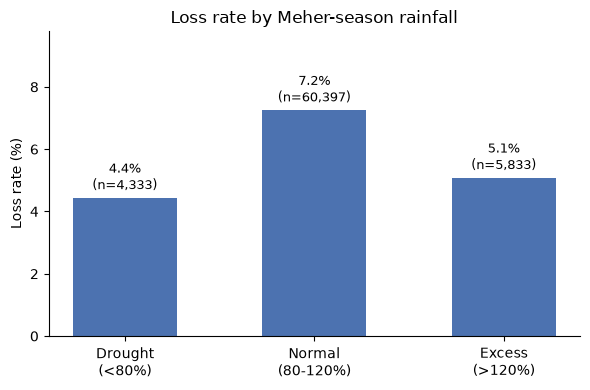

In [10]:
import matplotlib.pyplot as plt

BAR_COLOR = "#4C72B0"


def rain_bucket(pct):
    if pct < 80:
        return "Drought\n(<80%)"
    if pct > 120:
        return "Excess\n(>120%)"
    return "Normal\n(80-120%)"


df_model["meher_rain_bucket"] = df_model["rainfall_meher_pct_of_avg"].apply(rain_bucket)
bucket_order = ["Drought\n(<80%)", "Normal\n(80-120%)", "Excess\n(>120%)"]
loss_by_bucket = (df_model.groupby("meher_rain_bucket")["loss_occurred"].mean() * 100).reindex(bucket_order)
counts_by_bucket = df_model["meher_rain_bucket"].value_counts().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(loss_by_bucket.index, loss_by_bucket.values, color=BAR_COLOR, width=0.55)
ax.set_ylabel("Loss rate (%)")
ax.set_title("Loss rate by Meher-season rainfall")
ax.spines[["top", "right"]].set_visible(False)
for bar, val, n in zip(bars, loss_by_bucket.values, counts_by_bucket.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, f"{val:.1f}%\n(n={n:,})",
             ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, loss_by_bucket.max() * 1.35)
plt.tight_layout()
plt.show()

## Plot 2 — Loss rate by region and by crop

Horizontal bar charts, sorted by loss rate, for the categorical features
most likely to separate the classes: all 10 regions present in the data, and
the 15 most common crops (by row count) — rare crops are excluded here since
a loss rate computed on a handful of rows isn't a reliable signal.

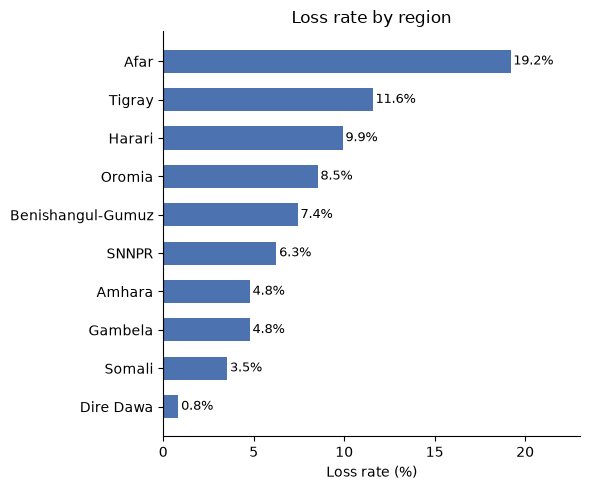

In [11]:
loss_by_region = (df_model.groupby("region_name")["loss_occurred"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.barh(loss_by_region.index, loss_by_region.values, color=BAR_COLOR, height=0.6)
ax.set_xlabel("Loss rate (%)")
ax.set_title("Loss rate by region")
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, loss_by_region.values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, loss_by_region.max() * 1.2)
plt.tight_layout()
plt.show()

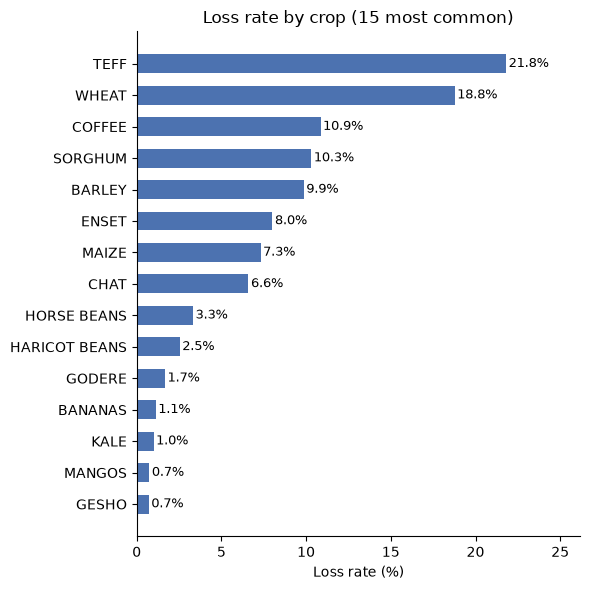

In [12]:
top_crops = df_model["crop_name"].value_counts().head(15).index
loss_by_crop = (
    df_model[df_model["crop_name"].isin(top_crops)]
    .groupby("crop_name")["loss_occurred"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.barh(loss_by_crop.index, loss_by_crop.values, color=BAR_COLOR, height=0.6)
ax.set_xlabel("Loss rate (%)")
ax.set_title("Loss rate by crop (15 most common)")
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, loss_by_crop.values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, loss_by_crop.max() * 1.2)
plt.tight_layout()
plt.show()

## Plot 3 — Outlier check on `household_size`

The rest of the feature set is either categorical (`crop_code`, `region_code`)
or already normalized (`rainfall_*_pct_of_avg`), where "outlier" doesn't
really apply, and tree-based models (the direction planned for this project)
aren't distorted by extreme values the way linear/distance-based models are.
`household_size` is the one plain numeric count worth a sanity check — a
boxplot catches both real extremes and, per this project's track record,
potential pipeline bugs (the duplicate-row check above already caught one).

count    70563.000000
mean         5.968638
std          2.365235
min          1.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         20.000000
Name: household_size, dtype: float64


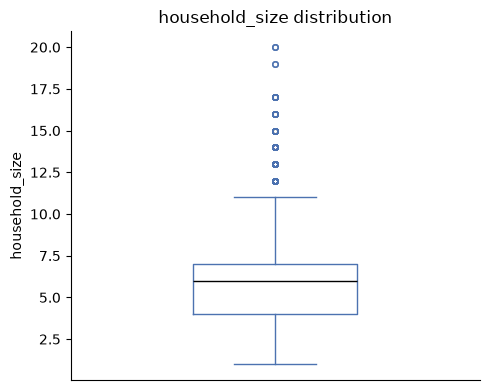

In [13]:
print(df_model["household_size"].describe())

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(df_model["household_size"], orientation="vertical", widths=0.4,
           boxprops=dict(color=BAR_COLOR), whiskerprops=dict(color=BAR_COLOR),
           capprops=dict(color=BAR_COLOR), medianprops=dict(color="black"),
           flierprops=dict(markeredgecolor=BAR_COLOR, markersize=4, alpha=0.5))
ax.set_ylabel("household_size")
ax.set_title("household_size distribution")
ax.set_xticks([])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Check for small sample sizes

A loss rate computed on very few rows is mostly noise, not signal — this
matters more here than usual because the base rate is only 6.5%, so a
category needs a fair number of rows just to expect a handful of loss cases
at all. Checking the three categorical features used above: `region_name`
and `survey_year` are low-cardinality (10 and 5 values) so every one of them
already has thousands of rows, but `crop_name` has 100 distinct values (after
the spelling merge above and dropping the `UNKNOWN` rows) —
Plot 2 already worked around this by only showing the 15 most common crops,
this makes explicit how much of the tail that left out.

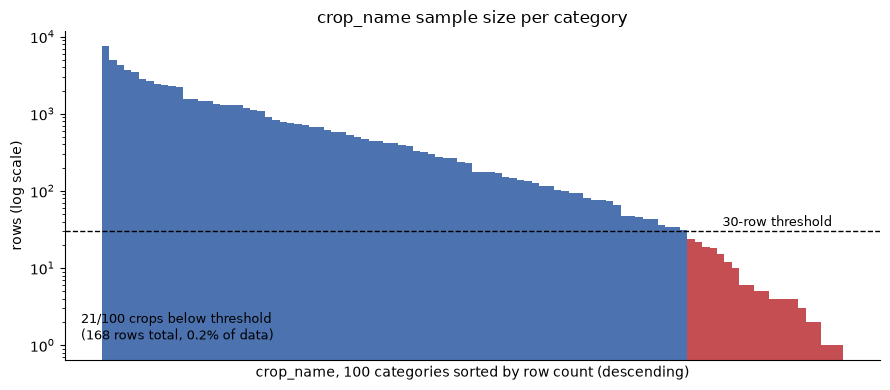

In [14]:
SMALL_SAMPLE_THRESHOLD = 30

crop_counts = df_model["crop_name"].value_counts().sort_values(ascending=False)
colors = [BAR_COLOR if n >= SMALL_SAMPLE_THRESHOLD else "#C44E52" for n in crop_counts.values]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(crop_counts)), crop_counts.values, color=colors, width=1.0)
ax.axhline(SMALL_SAMPLE_THRESHOLD, color="black", linewidth=1, linestyle="--")
ax.text(len(crop_counts) * 0.98, SMALL_SAMPLE_THRESHOLD + 5, f"{SMALL_SAMPLE_THRESHOLD}-row threshold",
        ha="right", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel(f"crop_name, {len(crop_counts)} categories sorted by row count (descending)")
ax.set_ylabel("rows (log scale)")
ax.set_title("crop_name sample size per category")
ax.set_xticks([])
ax.spines[["top", "right"]].set_visible(False)

n_small = (crop_counts < SMALL_SAMPLE_THRESHOLD).sum()
ax.text(0.02, 0.05, f"{n_small}/{len(crop_counts)} crops below threshold\n"
                     f"({crop_counts[crop_counts < SMALL_SAMPLE_THRESHOLD].sum()} rows total, "
                     f"{crop_counts[crop_counts < SMALL_SAMPLE_THRESHOLD].sum() / len(df_model) * 100:.1f}% of data)",
        transform=ax.transAxes, fontsize=9, va="bottom")

plt.tight_layout()
plt.show()

## Two leakage risks beyond target leakage — resolved here

These don't show up as a plot the way missingness/duplicates/outliers did —
they're about how the data is *used* (feature choice and train/test
splitting), not something wrong in a single column.

1. **Rainfall timing vs. the app's actual use.** `rainfall_annual_mm`/`_pct_of_avg`
   cover the full calendar year, including Oct-Jan — the window *after* a
   typical Meher harvest, i.e. during/after the loss event HarvestGuard is
   meant to warn about beforehand. Checked: ~16% of the annual total falls in
   that post-harvest window, and it's only moderately correlated with the
   Belg+Meher (growing-season) total (r=0.70/0.45), so it's not just a
   redundant re-statement of the seasonal figures — it carries real
   information a farmer wouldn't have yet at prediction time. This also
   matches `description.md`'s own pitch, which describes the app's input as
   "seasonal rainfall," not annual. **Decision: drop the annual rainfall
   columns, keep only `rainfall_belg_*`/`rainfall_meher_*`.** Applied below,
   in this notebook.
2. **Grouped leakage from `household_id`.** A household can report multiple
   crops, so the same household's rows could land on both sides of a naive
   random train/test split — letting the model partly recognize a specific
   household instead of learning a generalizable pattern. **Decision: at
   model-training time, split with `GroupShuffleSplit` (not plain
   `train_test_split`, which has no way to keep a household's rows
   together) grouped on `household_id`**, so every row from a given
   household stays entirely in train or entirely in test. This was verified
   feasible here (zero `household_id` overlap, matched loss rate across the
   split) but the actual split itself belongs in the modeling step, not this
   EDA/feature-prep notebook — `df_model` below stays whole.

In [15]:
df_model = df_model.drop(columns=["rainfall_annual_mm", "rainfall_annual_pct_of_avg"])
print("feature set after dropping annual rainfall:", df_model.shape)
print(list(df_model.columns))

feature set after dropping annual rainfall: (70563, 13)
['household_id', 'crop_name', 'survey_year', 'household_size', 'region_code', 'is_rural', 'region_name', 'rainfall_belg_mm', 'rainfall_belg_pct_of_avg', 'rainfall_meher_mm', 'rainfall_meher_pct_of_avg', 'loss_occurred', 'meher_rain_bucket']


## Drop `meher_rain_bucket` — verified redundant

`meher_rain_bucket` (added in Plot 1, above) is a bucketed version of
`rainfall_meher_pct_of_avg`, computed by applying a fixed function to that
same column — so it can only ever repeat information `rainfall_meher_pct_of_avg`
already carries, never add any. Verified rather than assumed: re-applying
the same bucketing function to `rainfall_meher_pct_of_avg` right now must
reproduce `meher_rain_bucket` exactly, for every row, with zero mismatches.
It was only ever meant as a display helper for that one chart, so it's
dropped from `df_model` here, finalizing this notebook's feature set.

In [16]:
recomputed_bucket = df_model["rainfall_meher_pct_of_avg"].apply(rain_bucket)
mismatches = (recomputed_bucket != df_model["meher_rain_bucket"]).sum()
print("mismatches between meher_rain_bucket and a fresh recompute:", mismatches)
assert mismatches == 0, "meher_rain_bucket isn't a pure function of rainfall_meher_pct_of_avg -- investigate before dropping"

df_model = df_model.drop(columns=["meher_rain_bucket"])

print("\nfinal clean feature set:", df_model.shape)
print(list(df_model.columns))

mismatches between meher_rain_bucket and a fresh recompute: 0

final clean feature set: (70563, 12)
['household_id', 'crop_name', 'survey_year', 'household_size', 'region_code', 'is_rural', 'region_name', 'rainfall_belg_mm', 'rainfall_belg_pct_of_avg', 'rainfall_meher_mm', 'rainfall_meher_pct_of_avg', 'loss_occurred']


## Final dataset status check

Quick health check on the final, cleaned `df_model` before modeling —
row/column count, dtypes, non-null counts, and memory usage in one command.

In [17]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70563 entries, 0 to 70562
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   household_id               70563 non-null  object 
 1   crop_name                  70563 non-null  object 
 2   survey_year                70563 non-null  int64  
 3   household_size             70563 non-null  float64
 4   region_code                70563 non-null  float64
 5   is_rural                   70563 non-null  float64
 6   region_name                70563 non-null  object 
 7   rainfall_belg_mm           70563 non-null  float64
 8   rainfall_belg_pct_of_avg   70563 non-null  float64
 9   rainfall_meher_mm          70563 non-null  float64
 10  rainfall_meher_pct_of_avg  70563 non-null  float64
 11  loss_occurred              70563 non-null  int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 6.5+ MB


## Final feature set summary

12 columns, 70,563 rows (down from 70,882 after merging crop-name spelling
variants and re-aggregating to the `household_id`+`crop_name`+`survey_year`
grain — see above), 100 distinct `crop_name` values, 0 missing
values, 0 duplicates. `crop_code` was dropped entirely (unreliable for Wave
2013 — see above); `crop_name` is the sole crop-identity feature, and rows
where it was missing (recoded as `"UNKNOWN"` in an earlier version of this
notebook) are now dropped rather than kept as a category — see "Handling the
remaining missing values" above. Target distribution: 93.1% no-loss / 6.9%
loss (up from 93.3%/6.7% before the `UNKNOWN`-row drop, since those rows
were 100% no-loss by construction; the pre-aggregation rate on the full
75,077-row dataset was 93.5%/6.5%, and the `"max"` collapse above nudges it
slightly). This is `df_model` as this notebook leaves it — whole, not split.
The train/test split (grouped on `household_id` via `GroupShuffleSplit`, not
plain `train_test_split` — see the leakage-risk section above) is a
model-training-time step, done in the next notebook rather than here.

| column | role |
|---|---|
| `household_id` | grouping key (not a model feature) |
| `crop_name` | feature (categorical) — also the only crop-identity field |
| `region_name` | display label |
| `household_size` | feature (numeric) |
| `region_code` | feature (categorical) |
| `is_rural` | feature (binary) |
| `survey_year` | feature (categorical/ordinal) |
| `rainfall_belg_mm` | feature (numeric) |
| `rainfall_belg_pct_of_avg` | feature (numeric) |
| `rainfall_meher_mm` | feature (numeric) |
| `rainfall_meher_pct_of_avg` | feature (numeric) |
| `loss_occurred` | **target** |

## Save the clean, unsplit dataset for the next stage (train/test split & modeling)

What we're doing here: persisting `df_model` — whole, `household_id` still
included, nothing split yet — as its own file, so the next notebook can load
one ready-to-use dataset instead of re-running this entire cleanup. The
actual train/test split (grouped on `household_id` via `GroupShuffleSplit`)
happens at the start of that next notebook, not here.

In [18]:
out_path = "../data/processed/crop_loss_model_ready.csv"
df_model.to_csv(out_path, index=False)
print(f"saved {df_model.shape} -> {out_path}")

saved (70563, 12) -> ../data/processed/crop_loss_model_ready.csv
